# Alcune analisi e grafici

---

## Heatmap fine tuning SVM: C v PCA 

Importiamo i risultati dal DataFrame salvato in pickle

In [6]:
import pandas as pd
df_plot_svm = pd.read_pickle("results/results-svm-savgol-fine-GridSearch.pkl")

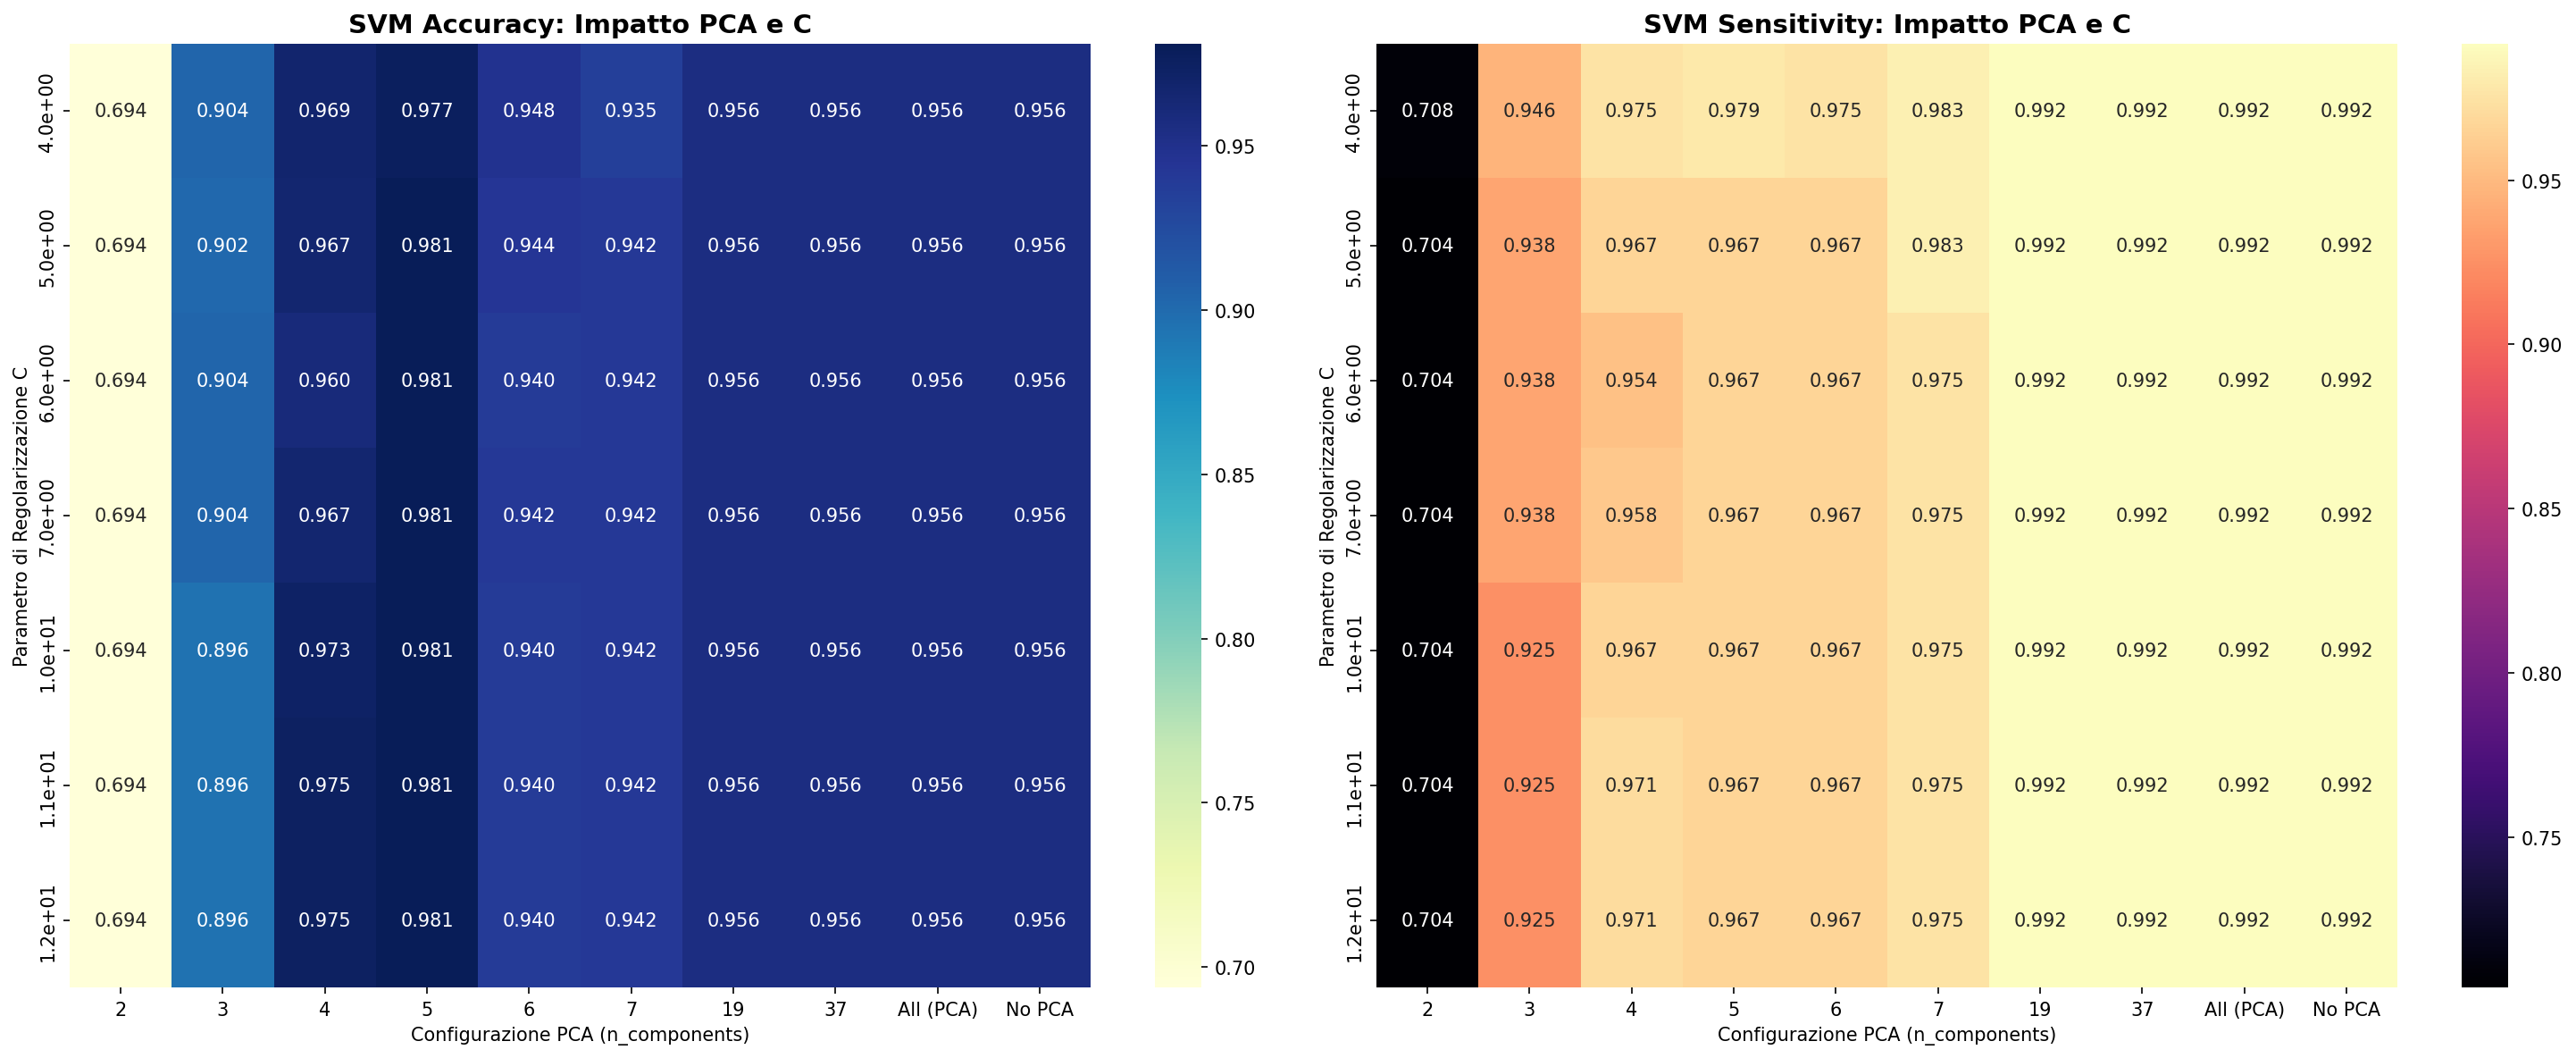

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Preparazione dei dati: Creazione di etichette univoche

def map_pca_labels(row):
    # Caso: Passthrough (Nessuna PCA eseguita)
    if row['param_reduce_dim'] == 'passthrough':
        return 'No PCA'
    # Caso: PCA con n_components=None (Tutte le componenti)
    elif pd.isna(row['param_reduce_dim__n_components']):
        return 'All (PCA)'
    # Caso: PCA con numero di componenti specifico
    else:
        return str(int(row['param_reduce_dim__n_components']))

df_plot_svm['n_comp_label'] = df_plot_svm.apply(map_pca_labels, axis=1)

# 2. Pivot delle tabelle
pivot_acc = df_plot_svm.pivot(index='param_classify__C', 
                          columns='n_comp_label', 
                          values='mean_test_score')

pivot_sens = df_plot_svm.pivot(index='param_classify__C', 
                           columns='n_comp_label', 
                           values='mean_test_sensitivity')

# 3. Ordinamento logico delle colonne
# Ordiniamo i numeri in modo crescente, poi mettiamo 'All (PCA)' e infine 'No PCA'
numeric_cols = sorted([c for c in pivot_acc.columns if c.isdigit()], key=int)
special_cols = []
if 'All (PCA)' in pivot_acc.columns: special_cols.append('All (PCA)')
if 'No PCA' in pivot_acc.columns: special_cols.append('No PCA')

ordered_columns = numeric_cols + special_cols
pivot_acc = pivot_acc[ordered_columns]
pivot_sens = pivot_sens[ordered_columns]

# 4. Creazione della figura
fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

# --- Heatmap Accuracy ---
sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title('SVM Accuracy: Impatto PCA e C', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Configurazione PCA (n_components)')
axes[0].set_ylabel('Parametro di Regolarizzazione C')

# --- Heatmap Sensitivity ---
sns.heatmap(pivot_sens, annot=True, fmt=".3f", cmap="magma", ax=axes[1])
axes[1].set_title('SVM Sensitivity: Impatto PCA e C', fontweight='bold', fontsize=14)
axes[1].set_xlabel('Configurazione PCA (n_components)')
axes[1].set_ylabel('Parametro di Regolarizzazione C')

# Formattazione asse Y: Notazione scientifica per i valori di C
y_labels = [f'{float(t.get_text()):.1e}' for t in axes[0].get_yticklabels()]
axes[0].set_yticklabels(y_labels)
axes[1].set_yticklabels(y_labels)

plt.tight_layout()
plt.show()

---

## Heatmap fine tuning RF: estimators v PCA 

In [8]:
df_plot_rf = pd.read_pickle("results/results-rf-savgol-fine-GridSearch.pkl")

In [9]:
df_plot_rf

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classify__n_estimators,param_reduce_dim__n_components,param_reduce_dim,params,split0_test_score,split1_test_score,...,split53_test_sensitivity,split54_test_sensitivity,split55_test_sensitivity,split56_test_sensitivity,split57_test_sensitivity,split58_test_sensitivity,split59_test_sensitivity,mean_test_sensitivity,std_test_sensitivity,rank_test_sensitivity
0,0.060543,0.013750,0.005959,0.003492,50,2,NaN,"{'classify__n_estimators': 50, 'reduce_dim__n_...",0.750,0.500,...,1.00,0.50,0.75,1.00,0.75,1.00,0.25,0.641667,0.234373,42
1,0.062772,0.012041,0.005988,0.003063,50,5,NaN,"{'classify__n_estimators': 50, 'reduce_dim__n_...",1.000,1.000,...,0.75,0.75,1.00,0.75,1.00,0.75,1.00,0.937500,0.134048,10
2,0.062401,0.019844,0.006704,0.003828,50,7,NaN,"{'classify__n_estimators': 50, 'reduce_dim__n_...",1.000,0.875,...,0.75,0.75,0.75,0.75,1.00,0.75,0.75,0.925000,0.123322,21
3,0.062765,0.010663,0.006402,0.003822,50,19,NaN,"{'classify__n_estimators': 50, 'reduce_dim__n_...",1.000,0.750,...,1.00,1.00,1.00,0.50,0.75,1.00,1.00,0.929167,0.144998,17
4,0.064374,0.011567,0.007602,0.004308,50,37,NaN,"{'classify__n_estimators': 50, 'reduce_dim__n_...",1.000,0.875,...,0.75,1.00,0.75,0.75,1.00,0.75,0.75,0.904167,0.121550,34
5,0.064210,0.018449,0.006730,0.004282,50,None,NaN,"{'classify__n_estimators': 50, 'reduce_dim__n_...",1.000,0.875,...,0.75,1.00,1.00,0.75,1.00,1.00,0.75,0.904167,0.137626,34
6,0.121013,0.022105,0.012732,0.016338,100,2,NaN,"{'classify__n_estimators': 100, 'reduce_dim__n...",0.500,0.500,...,1.00,0.50,0.75,1.00,0.75,1.00,0.50,0.675000,0.242813,39
7,0.120647,0.023568,0.010018,0.007501,100,5,NaN,"{'classify__n_estimators': 100, 'reduce_dim__n...",1.000,1.000,...,1.00,1.00,0.75,0.75,1.00,0.75,1.00,0.937500,0.126037,10
8,0.121940,0.015040,0.011639,0.005967,100,7,NaN,"{'classify__n_estimators': 100, 'reduce_dim__n...",1.000,0.875,...,0.75,0.75,0.75,0.75,1.00,1.00,0.75,0.941667,0.115169,8
9,0.126396,0.017141,0.010238,0.004609,100,19,NaN,"{'classify__n_estimators': 100, 'reduce_dim__n...",1.000,0.750,...,1.00,1.00,1.00,0.50,0.75,1.00,1.00,0.937500,0.117482,10


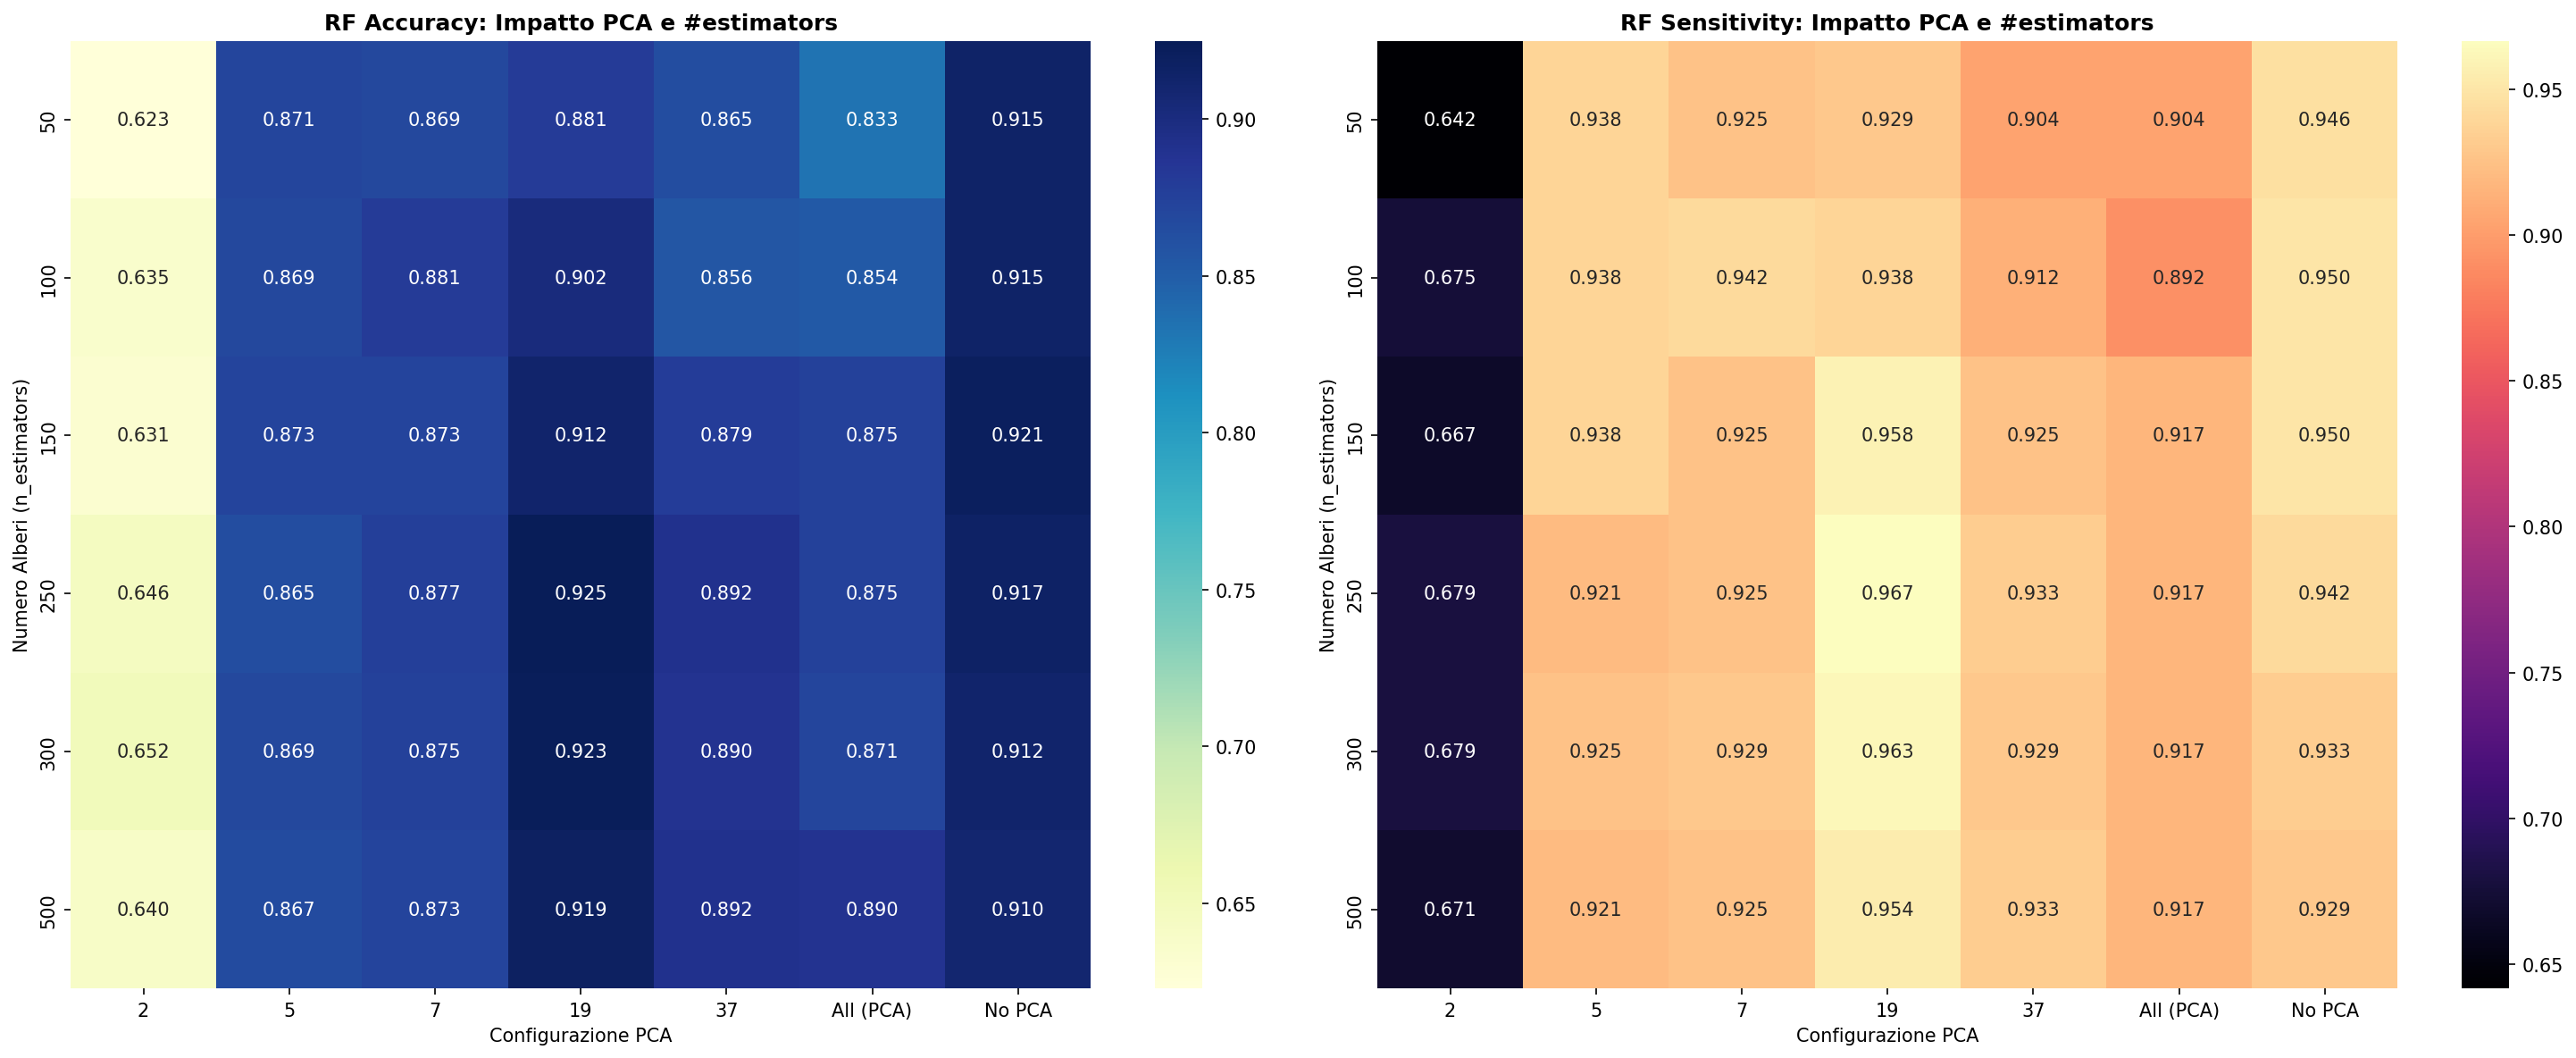

In [11]:
# 1. Creiamo una colonna "n_comp_label" che distingua i casi
def create_label(row):
    # Se lo step reduce_dim è 'passthrough', allora non c'è PCA
    if row['param_reduce_dim'] == 'passthrough':
        return 'No PCA'
    # Se è PCA ma n_components è None, sono tutte le componenti
    elif pd.isna(row['param_reduce_dim__n_components']):
        return 'All (PCA)'
    # Altrimenti è il numero di componenti
    else:
        return str(int(row['param_reduce_dim__n_components']))

df_plot_rf['n_comp_label'] = df_plot_rf.apply(create_label, axis=1)

# 3. Ora facciamo il pivot sulla nuova colonna
pivot_acc = df_plot_rf.pivot(index='param_classify__n_estimators', 
                          columns='n_comp_label', 
                          values='mean_test_score')

pivot_sens = df_plot_rf.pivot(index='param_classify__n_estimators', 
                           columns='n_comp_label', 
                           values='mean_test_sensitivity')

# Ordiniamo le colonne per renderle leggibili (No PCA e All alla fine)
cols = sorted([c for c in pivot_acc.columns if c.isdigit()], key=int)
if 'All (PCA)' in pivot_acc.columns: cols.append('All (PCA)')
if 'No PCA' in pivot_acc.columns: cols.append('No PCA')

pivot_acc = pivot_acc[cols]
pivot_sens = pivot_sens[cols]

# 4. Disegniamo le Heatmap
fig, axes = plt.subplots(1, 2, figsize=(20, 8), dpi=150)

sns.heatmap(pivot_acc, annot=True, fmt=".3f", cmap="YlGnBu", ax=axes[0])
axes[0].set_title('RF Accuracy: Impatto PCA e #estimators', fontweight='bold')
axes[0].set_xlabel('Configurazione PCA')
axes[0].set_ylabel('Numero Alberi (n_estimators)')

sns.heatmap(pivot_sens, annot=True, fmt=".3f", cmap="magma", ax=axes[1])
axes[1].set_title('RF Sensitivity: Impatto PCA e #estimators', fontweight='bold')
axes[1].set_xlabel('Configurazione PCA')
axes[1].set_ylabel('Numero Alberi (n_estimators)')

plt.tight_layout()
plt.show()